<a href="https://colab.research.google.com/github/SarahPauwels-ucll/prog_for_data_analysis/blob/main/load_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**
Air pollution is one of the biggest environmental challenges in China. To understand how polluted the air is at a specific moment we can use the Air Quality Index (AQI). Monitoring the trends and changes can help us understand the impact of the Air pollution on public health and urban sustainability.

By using different mesuring advices for each specific air pollutent we can can establish the general quality of the air in different areas and we can see what pollutent we need to focus on to improve the quality.


## **Air Quality Index**
To understand this project we will need to know how the AQI works. Air quality is based on the measurements levels of six different pollutants in the air. These are PM2.5, PM10, SO2, NO2,O3 and CO. The general public looses interest and can easily get confused if they need to look at each of these pollutants seperatly, Because of this they may not understand how good or bad the air quality actually is.

There for many countries developed an AQI. AQI turns the complex pollutions measurements into one number. This number can be represented by a category ranging from "Good" to "Hazardous". This makes it easier for people to understand the air qualitly quickly and take the necessary precautions.

This is especially important for people with health issues, but it can be important for everyone. A well-informed public is also more likely to support actions and policies that help improve air quality.

## **The dataset**

The data set used for this project will help us to analyse and understand the patterns of the pollutants and the overal air quality. The dataset has messurement from different cities spannig from  March 2013 until February 2017. giving us four years of air quality condidions.

## **Research Objectives**

build an applications that helps to build a data-driven system that is capable of monitoring and forecasting air pollution in china. We will do this by predicting different types of pollutions and calculating the AQI level.

## **Research Questions**

* Which pollutants influence overall AQI levels in different regions of China?
* What seasonal patterns and long-term trends can be observed in AQI across Chinees cities?
* Can machine learning models effectively predict AQI values using historical air quality data?
* which pollutens have the biggest effect on tha AQI in Chinees cities?
* what are the differences in airpollution between urban and suburban areas?






## **Importing the required libraries**

In [ ]:
# importing the necessary libraries for data analysis
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

## **Cloning the GitHub Repository:**


This sets the 'user.name' and 'user.email' properties in the global Git configuration file.
These values are used for identifying the author of commits.

In [ ]:
! git config --global user.name "SarahPauwels-ucll"

These are variables for the GitHub username, repository namewhich are used for accessing and interacting with the repository.

This command clones the GitHub repository using provided credentials.

In [ ]:
username = "SarahPauwels-ucll"
repo = "prog_for_data_analysis"


In [ ]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'prog_for_data_analysis'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 147 (delta 74), reused 56 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 12.91 MiB | 5.69 MiB/s, done.
Resolving deltas: 100% (74/74), done.
Updating files: 100% (20/20), done.


This command changes the current working directory to the specified repository folder.

In [ ]:
%cd {repo}

/content/prog_for_data_analysis


This command lists all files and directories within the current working directory.

In [ ]:
%ls

data/  load_data.ipynb  pages/  README.md  streamlit_app.py


In [ ]:
%cd data/

/content/prog_for_data_analysis/data


# **Task 1 - Data Selection & Handling**

### **Objective :**

* Select 2 inner (urban) and 2 outer (suburban) stations
* Download the four selected datasets
* Import them into your development environment.
* Merge them into a single unified dataset for analysis

The first step is to chose 2 inner and 2 outer stations that we will use for this assigment. The Xu&
Zhang(2004) mentiond that even though all stations had high data availability, the AT station still had only 68% in hourly PM2.5 in 2013. To make our analysis as accurate as possible it's important that we have accurate data there for we will chose the 2 inner and 2 outer stations that have the least amount of missing data.

To do this we put all the data in github. By cloning github (in the previous step) all the data should be in the working directory. We then need to combine them into one data frame so that we can compare the missing values per station.

### **Merging of the csv files:**
---

In [ ]:
# Import the necessary libraries
import pandas as pd  # pandas is used for working with data tables
import glob         # glob is used to find files by name patterns

# STEP 1: find all the city files
city_files = glob.glob("PRSA_Data_*.csv")
print(city_files)

# STEP 2: Create an empty list to store all our city data
# We'll put each city's data in this list before combining them
all_cities_data = []

# STEP 3: Read each city file one by one
for file_name in city_files:

    # Read the current city's CSV file into a DataFrame
    # A DataFrame is like a spreadsheet table in Python
    city_df = pd.read_csv(file_name)

    # Add this city's data to our list
    all_cities_data.append(city_df)

    # Optional: Print which file we just read
    print(f"Loaded: {file_name}")

# STEP 4: Combine all city data into one big table
# pd.concat() joins all the DataFrames in our list together
# ignore_index=True makes sure the row numbers are continuous (0, 1, 2, 3...)
combined_data = pd.concat(all_cities_data, ignore_index=True)

['PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv']
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Shunyi_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Aotizhongxin_20130301-20170228.csv
Loaded: PRSA_Data_Wanshouxigong_20130301-20170228.csv
Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Tiantan_20130301-20170228.csv
Loaded: PRSA_Data_Wanliu_20130301-20170228.csv
Loaded: PRSA_Data_Nongzhanguan_20130301-20170228.csv
Loaded: PRSA_Data

Check if the combined_data is correct.

In [ ]:
combined_data

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
420764,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
420765,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
420766,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


/tmp/ipykernel_8952/1164836996.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_data = df.groupby('station').apply(lambda x: x.isnull().mean() * 100)


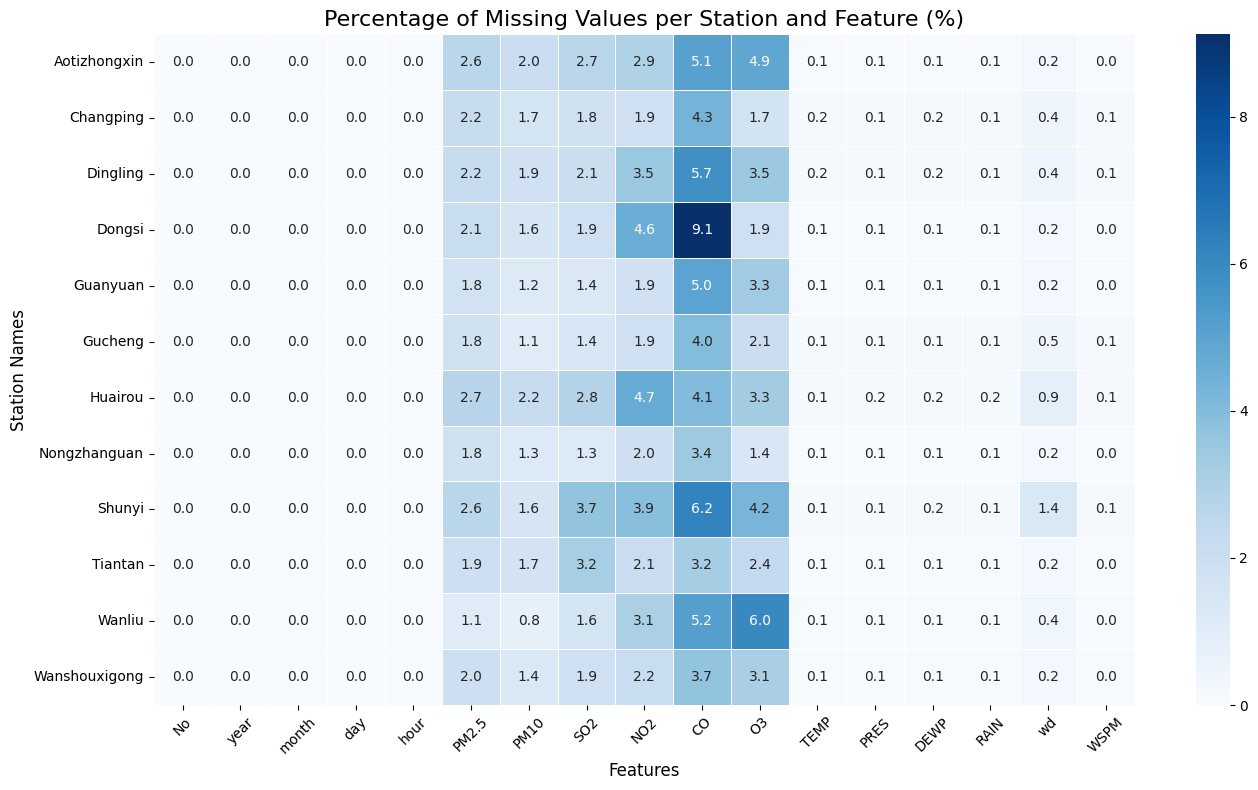

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_missing_values_heatmap(df):
    # Calculate percentage of missing values per group (station) per column
    missing_data = df.groupby('station').apply(lambda x: x.isnull().mean() * 100)

    # 2. Remove the group_col from the columns since its missing value count is irrelevant
    if 'station' in missing_data.columns:
        missing_data = missing_data.drop(columns=['station'])

    # 3. Create the heatmap plot
    plt.figure(figsize=(14, 8))
    sns.heatmap(missing_data, annot=True, cmap='Blues', fmt=".1f", linewidths=.5)

    plt.title('Percentage of Missing Values per Station and Feature (%)', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Station Names', fontsize=12)
    plt.xticks(rotation=45)      # Rotate x labels for better readability
    plt.tight_layout()

    plt.show()

plot_missing_values_heatmap(combined_data)

for the outer stations we need to chose between Changpingzhen, Dingling, Huairouzhen and Shunyixincheng. by looking at the heatmap we can see that **Changpingzhen** has the least amount of missing values over all the features. Huairouzhen has more missing values for NO2 than Dingling, but it has more values for CO and O3 so we chose **Huairouzhen.**

for the inner stations we need to chose between Aotizhongxin, Dongsi, Guanyuan, Nongzhanguan, Tiantan,Wanshouxigong, Gucheng and
Haidianquwanliu. here we chose **Nongzhanguan and Gucheng**

Then we have to merge them into a single unified dataset for analysis.

In [ ]:
selected_stations = ['Nongzhanguan', 'Tiantan', 'Huairou', 'Gucheng']

#this keeps only rows where the 'station' column selected
selecteddf = combined_data[combined_data['station'].isin(selected_stations)]

selecteddf.to_csv("selected_combined.csv", index=False)

Load the data in.

In [ ]:
df= pd.read_csv('selected_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


Check if the merge of the 4 stations was correct.

In [ ]:
stations = df['station'].value_counts()
print(f'Total number of stations in the dataset : {len(stations)}')
stations

Total number of stations in the dataset : 4


,count
station,
Gucheng,35064
Tiantan,35064
Nongzhanguan,35064
Huairou,35064


# **Task 2: Exploratory Data Analysis (EDA)**
## **2.1.Data Understanding**

### **Objective :**
Provide an overview that may include the following, but not limited to:
* Number of rows and columns
* Column descriptions
* Data types
* Missing values
* Statistical Summary
* Initial observations & interpretation

I looked at the head and the tail of the data set to get an understanding of what the data looks like.

In [ ]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [ ]:
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou
140255,35064,2017,2,28,23,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,NE,1.9,Huairou


we want to see the amount of rows to know how many data points we have. The amount of columns tells us how many things we track.

In [ ]:
df.shape
print(f'No of Rows: {df.shape[0]}, No of Columns: {df.shape[1]}')

No of Rows: 140256, No of Columns: 18


By looking at the column names we can see what exactly we track and how the data is stored.

In [ ]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137352 non-null  float64
 6   PM10     138061 non-null  float64
 7   SO2      137205 non-null  float64
 8   NO2      136513 non-null  float64
 9   CO       135101 non-null  float64
 10  O3       137027 non-null  float64
 11  TEMP     140114 non-null  float64
 12  PRES     140113 non-null  float64
 13  DEWP     140112 non-null  float64
 14  RAIN     140118 non-null  float64
 15  wd       139639 non-null  object 
 16  WSPM     140137 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB


We can see that wd is an object so its important to know what the possible wd are.  

In [ ]:
df['wd'].unique()

array(['NW', 'WNW', 'W', 'E', 'ENE', 'NE', 'ESE', 'SSE', 'NNE', 'SW',
       'SSW', 'S', 'SE', 'NNW', 'N', 'WSW', nan], dtype=object)

We then make a table to explain all the columns and there unit.

**Description of the columns**

| Column | Description |Typical Unit |
| :--- | :--- | :--- |
| **PM2.5** | Fine Particulate Matter | $\mu g/m^3$ |
| **PM10** | Fine/Coarse Particulate Matter <br> (PM2.5 is included in PM10 to just find coarse particulare matter you need to exclude PM2.5 from PM10) | $\mu g/m^3$ |
| **SO2** | Sulfur Dioxide | $\mu g/m^3$ |
| **NO2** | Nitrogen Dioxide| $\mu g/m^3$ |
| **O3** |  Ozone | $\mu g/m^3$ |
| **CO** | Carbon Monoxide | $\mu g/m^3$  |
| **TEMP** | Temperature | $^\circ$C |
| **DEWP** | Dew Point Temperature| $^\circ$C |
| **PRES** | Barometric Pressure | hPa |
| **RAIN** | Hourly Precipitation | mm |
| **WSPM** | Wind Speed | m/s |
| **Wd** | Wind Direction |  |

## **Missing values**

Then we check the amount of missing values and see if there are any columns that have a lot of missing data. We can see that CO has the most amount of missing data and that's only 3.7% so there are no major gaps.

In [ ]:
def missing_values_table(df):
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(df)
display(missing_values.style.background_gradient(cmap='Blues'))

,Missing Values,% of Total Values
CO,5155,3.675422
NO2,3743,2.668692
O3,3229,2.302219
SO2,3051,2.175308
PM2.5,2904,2.070500
PM10,2195,1.564995
wd,617,0.439910
DEWP,144,0.102669
PRES,143,0.101956
TEMP,142,0.101243


Next we check if there are any rows that are duplicats and we can see that there are no duplicates.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


We look at the statistical data of each feature to a better idea of all the columns.

In [ ]:
df.describe().T #transposed for beter readablility

,count,mean,std,min,25%,50%,75%,max
No,140256.0,17532.500000,10122.141000,1.0000,8766.75,17532.5,26298.25,35064.0
year,140256.0,2014.662560,1.177201,2013.0000,2014.00,2015.0,2016.00,2017.0
month,140256.0,6.522930,3.448715,1.0000,4.00,7.0,10.00,12.0
day,140256.0,15.729637,8.800123,1.0000,8.00,16.0,23.00,31.0
hour,140256.0,11.500000,6.922211,0.0000,5.75,11.5,17.25,23.0
PM2.5,137352.0,80.144075,80.736633,2.0000,21.00,56.0,111.00,844.0
PM10,138061.0,106.466717,91.968006,2.0000,37.00,84.0,148.00,995.0
SO2,137205.0,15.151537,21.370441,0.2856,2.00,7.0,18.00,500.0
NO2,136513.0,50.027617,34.612192,1.0265,23.00,43.0,70.00,276.0
CO,135101.0,1242.562216,1146.399290,100.0000,500.00,900.0,1500.00,10000.0


## **Key findings data understanding**
By looking at the data we can see that there are 4 colums that tell us when they took the mesurement. The year, month, day and hour column.

there are no duplicates in this data set so we don't need to worry about that, however there is missing data.
This missing data is pressent in almost all columns accept the year, month, day,hour, no and station column.

We are also missing a column that gives us the the AQI, however we can calculate this using the other columns.

Since PM10 includes PM2.5 we could make a new column so the columns are not impacted by eachother and make a 2.5-10 colum that displays only the particals that are smaler then 10 but still larger than 2.5.




# **Task 2: Exploratory Data Analysis (EDA)**
## **2.2.Data preprocessing:**

### **Objective :**
Perform the necessary data preprocessing steps, including but not limited to handling missing values,
removing duplicate entries, feature engineering (e.g., datetime components, AQI levels), and overall data
cleaning on the main dataset.

**Make 1 datetime column**

In [ ]:
import pandas as pd

# Create the new datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Drop the old columns
df = df.drop(columns=['year', 'month', 'day', 'hour'])

#verify
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,2,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,3,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,4,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00


The NO column tells us nothing about the data except the order of the mesurements, however we can also read this from the datatime column. Therefor we can drop this column.

In [ ]:
df = df.drop(columns=['No'])


Making a new feature that only displays the Coarse Particulate Matter

In [ ]:
df['PM2.5-10'] = df['PM10'] - df['PM2.5']
#is should never be lower then 0 if lower than there is a calibration issue
df['PM2.5-10'] = df['PM2.5-10'].clip(lower=0)

##**Fill missing colums**
the most accurate way to fill most of the missing values in this data set is to use linear interpolation. This is because 'PM2.5', 'PM10', 'SO2', 'NO2', 'O3' and 'CO' are all values that display polution and polution builds up and clears up gradually.

'TEMP', 'PRES', 'WSPM'and'DEWP' display the weather and the weather usually also changes gradually so here we use linear interpolation aswell. However if we look at rain specificaly we can see that almost all the values are zero. Therefor I chose to fill the missing rain values with 0.

the WD also usually doesn't change imedatly, but it is catogorical data, therefor I chose to forward fill.

In [ ]:

numeric_cols = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO', 'TEMP', 'PRES', 'WSPM','DEWP']
df[numeric_cols] = df.groupby('station')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both'))

df['wd'] = df.groupby('station')['wd'].ffill()

df = df.fillna({'RAIN': 0})

df['PM10'] = np.where(df['PM10'].isna(),df['PM2.5'] + df['PM2.5-10'], df['PM10']
)

df.isnull().sum()

,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
...,...
O3_roll_std_6,0
O3_roll_max_6,0
O3_roll_mean_24,0
O3_roll_std_24,0


There are no duplicates so there is no need to remove them

In [ ]:
df.to_csv("preprocesed.csv", index=False)

# **Task 2: Exploratory Data Analysis (EDA)**
## **2.3.Statistical/Computational Analysis & Visualisation**

### **Objective :**
* Perform the necessary steps such as univariate (distribution of pollutants & meteorological variables),
bivariate(e.g. relationships such as PM2.5 vs. Temp, NO2 vs. O3 but not limited to these), and
multivariate analysis (correlation, heatmaps, pairplots), statistical summary, and visualizing the data
(Various charts and graphs, such as bar charts, line charts and scatter plots) that will help in
understanding relationships between variables and to gain important insights from data. Interpret the
key results to demonstrate understanding generated from statistical and visual analysis.
* Explore the dataset however you find meaningful. You may examine different variables, compare
stations, investigate temporal behaviours, or analyse interactions between pollutants and
meteorological factors. Choose the approaches that you believe best help you understand and interpret
the dataset, and present the insights you consider most relevant



In [1]:
import pandas as pd
df= pd.read_csv("preprocesed.csv")
df.describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,PM2.5-10
count,140256.000000,138061.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,80.172279,106.466717,15.355655,49.813368,1247.718201,58.363282,13.405720,1010.387937,2.427341,0.065043,1.679517,27.899724
std,80.844864,91.968006,22.041818,34.654066,1151.971693,57.686731,11.507293,10.402816,13.869439,0.815164,1.247344,43.015761
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000,0.000000
25%,21.000000,37.000000,2.000000,23.000000,500.000000,11.000000,3.000000,1002.000000,-9.100000,0.000000,0.900000,0.000000
50%,56.000000,84.000000,7.000000,42.000000,900.000000,45.000000,14.400000,1010.000000,3.000000,0.000000,1.400000,14.000000
75%,111.000000,148.000000,19.000000,70.000000,1500.000000,83.000000,23.200000,1018.600000,15.100000,0.000000,2.200000,39.000000
max,844.000000,995.000000,500.000000,276.000000,10000.000000,674.000000,41.600000,1042.000000,29.100000,46.400000,12.900000,952.000000


In [8]:
pollutants = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO']
stats_summary = df.groupby('station')[pollutants].agg(['mean', 'std', 'max'])
print(stats_summary)

                  PM2.5                     PM2.5-10                    \
                   mean        std    max       mean        std    max   
station                                                                  
Gucheng       84.074802  82.994634  770.0  36.299837  49.599810  926.0   
Huairou       69.501747  70.990900  762.0  23.866986  41.304515  952.0   
Nongzhanguan  85.079472  86.692516  844.0  25.831105  39.238290  800.0   
Tiantan       82.033097  80.895489  821.0  25.600968  39.991782  812.0   

                    SO2                          NO2                    \
                   mean        std    max       mean        std    max   
station                                                                  
Gucheng       15.705821  23.282583  500.0  55.822315  36.522738  276.0   
Huairou       12.446681  19.361831  315.0  32.077275  26.269586  231.0   
Nongzhanguan  18.760102  24.379948  257.0  58.095053  36.380351  273.0   
Tiantan       14.510018  20.277493  2

## Distribution
First we look at the distribution of all of the plutants. We can see that all of the polutants are right skewed.

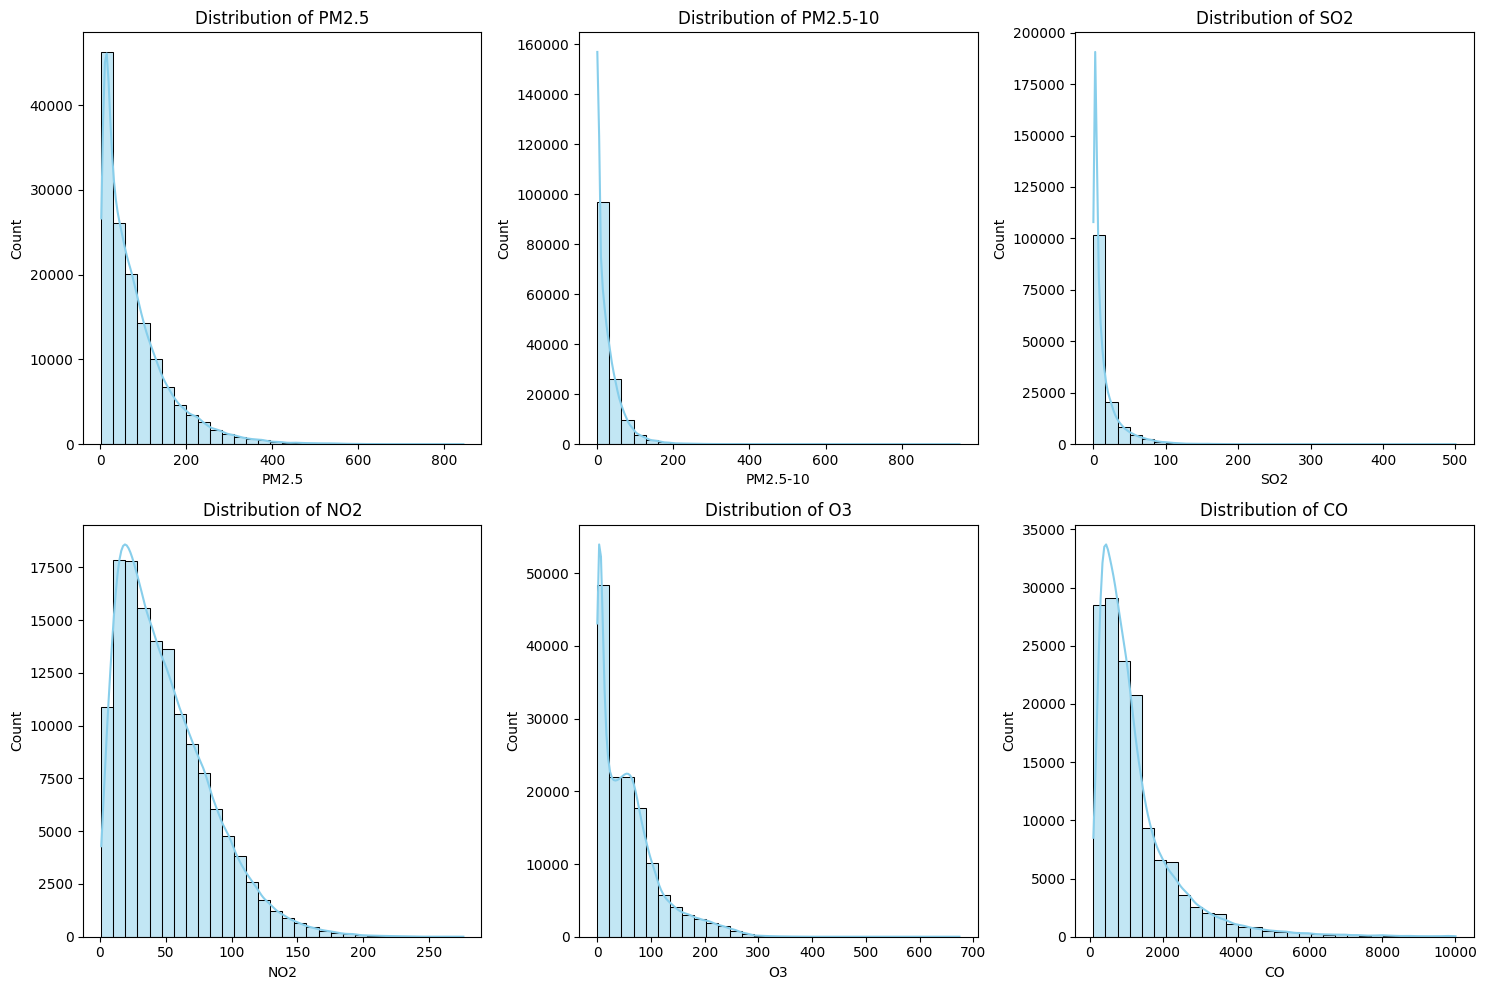

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

We then do the same thing but grouped per station to compaire the distribution across the different stations.

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


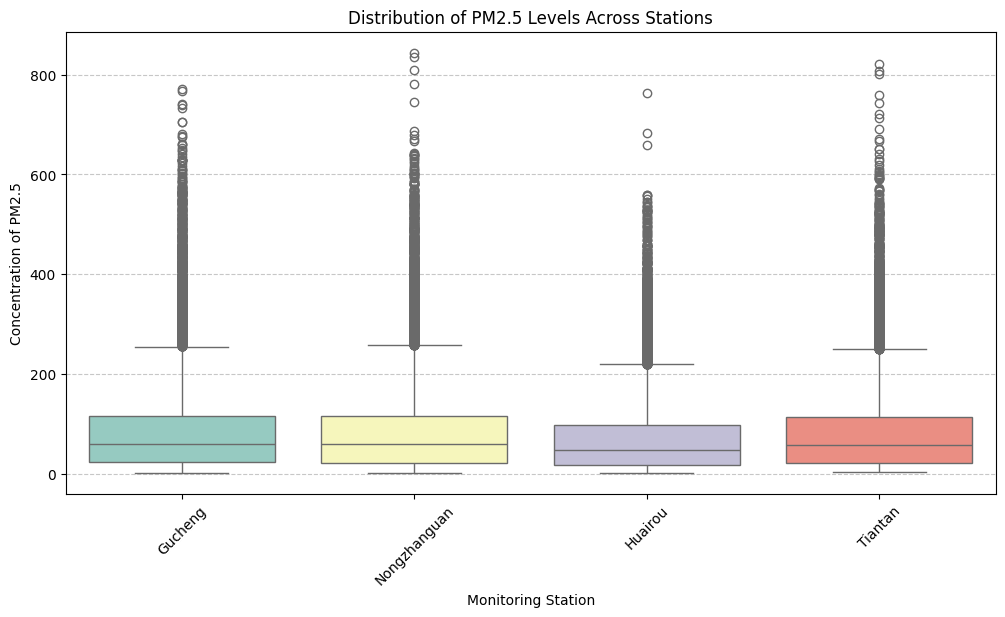

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


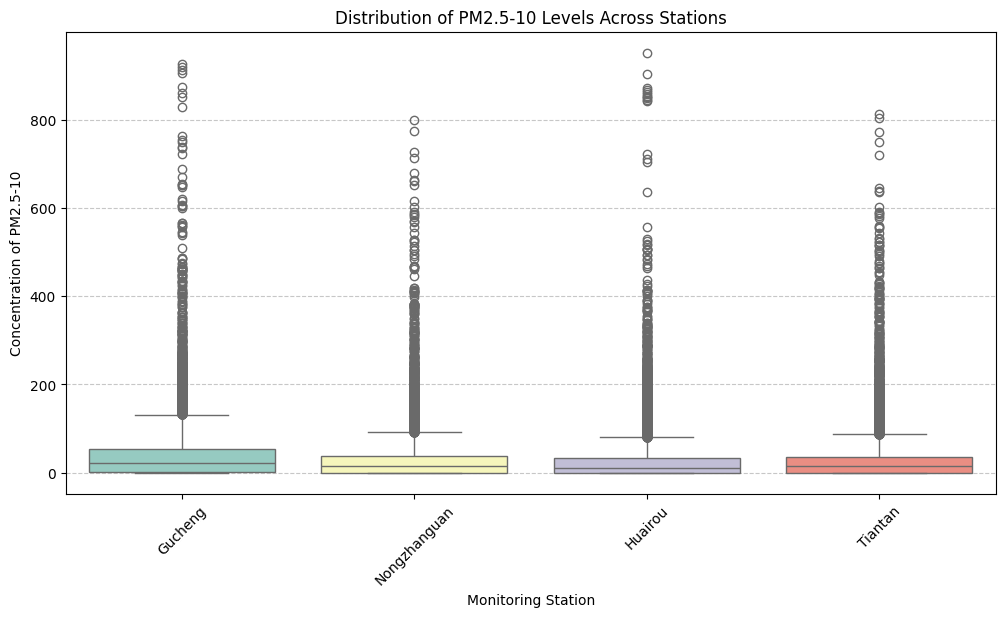

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


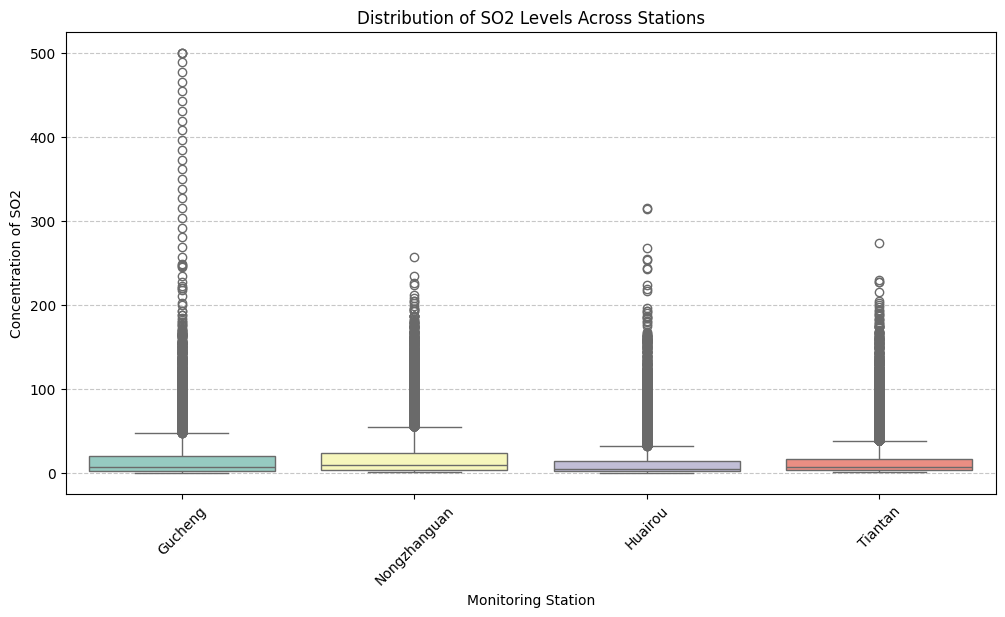

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


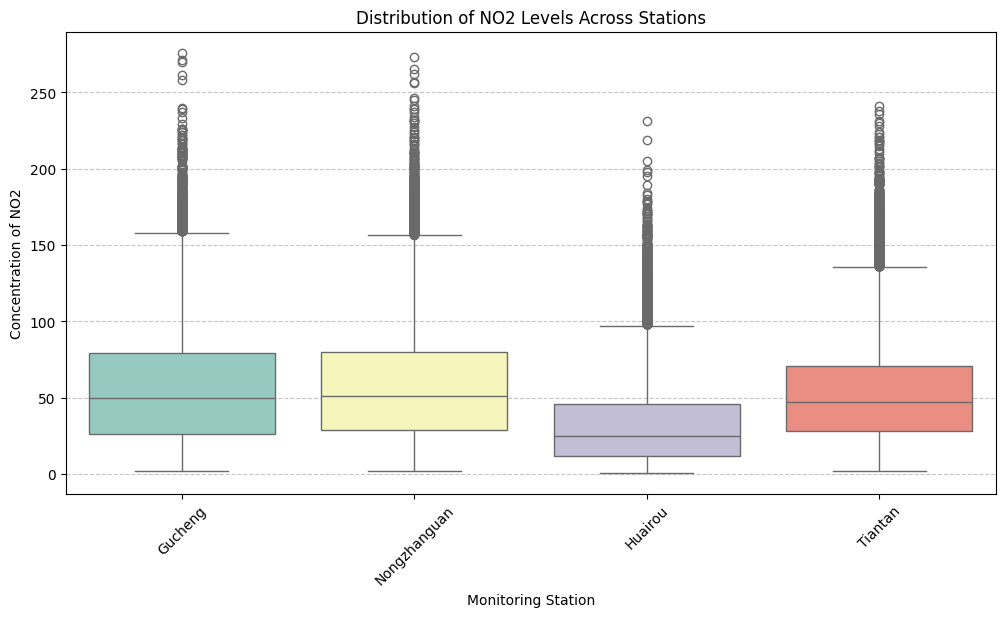

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


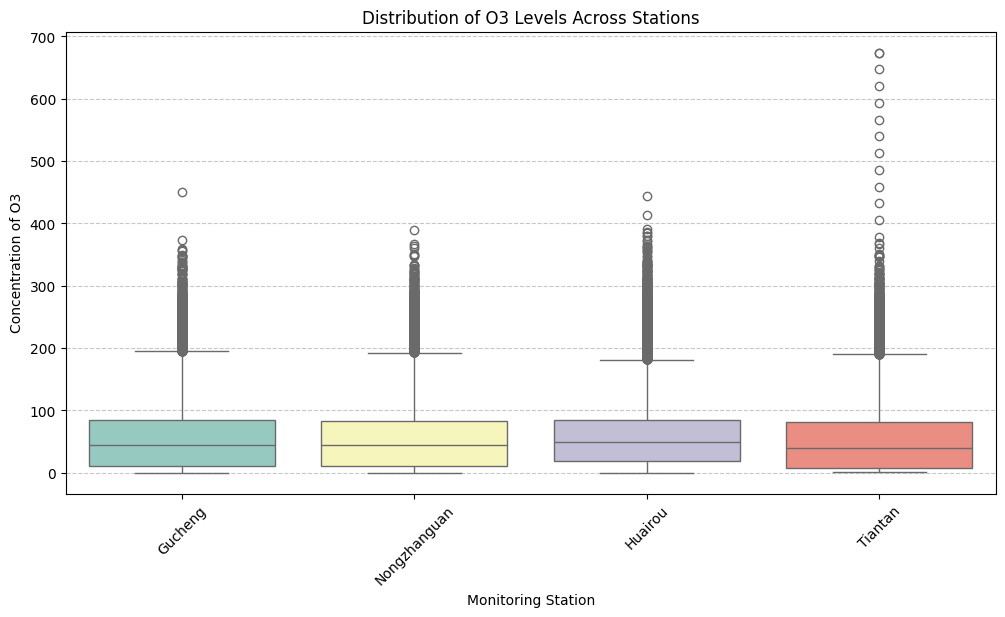

/tmp/ipykernel_8599/3663384676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")


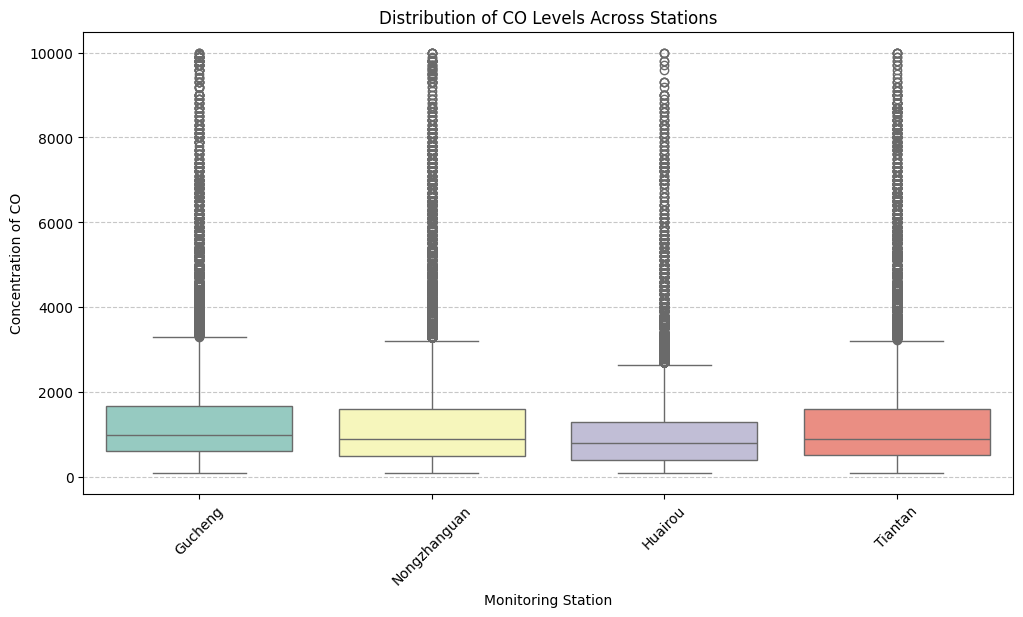

In [10]:
pollutants = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO']

# Generating boxplots for each pollutant
for pollutant in pollutants:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='station', y=pollutant, data=df, palette="Set3")
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {pollutant} Levels Across Stations')
    plt.ylabel(f'Concentration of {pollutant}')
    plt.xlabel('Monitoring Station')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

## Correlation

To get a quick overview of the correlation we make a correlation heatmap of all the pollutants and the meteorological factors.
We can see that 'PM2.5', 'SO2', 'NO2' and 'CO' are more correlated to eachother and O3 is more correlated to the meteorological factors except pressure and rain. 'PM2.5-10' is not Correlated to anything.

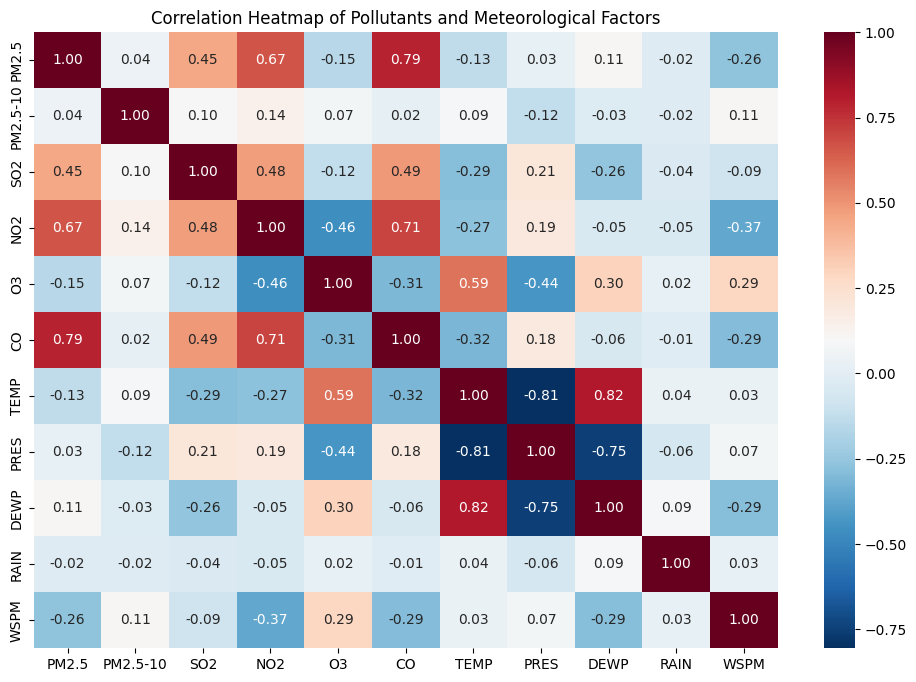

In [11]:
# Calculate correlation matrix
corr_matrix = df[['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title("Correlation Heatmap of Pollutants and Meteorological Factors")
plt.show()

O3 had the highest correlation with temperature so we try to get a better understanding of the temperature vs O3.

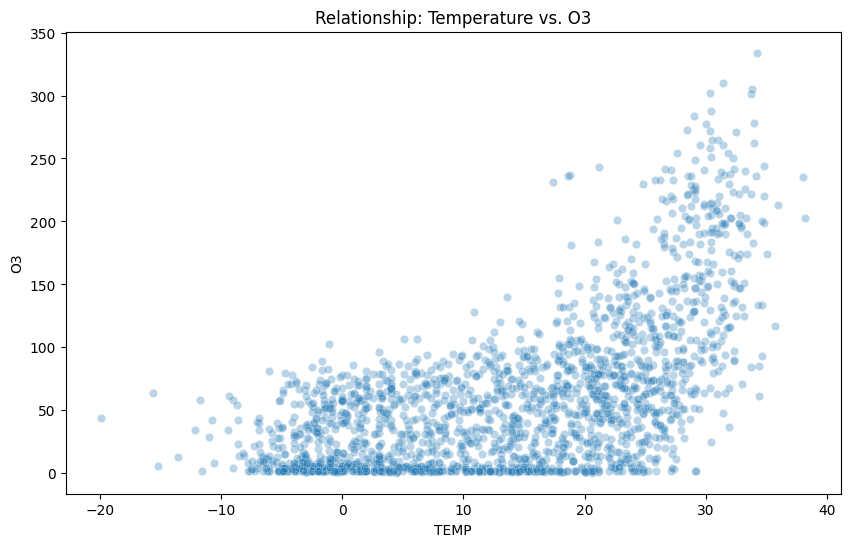

In [7]:
# Relationship between Temperature and O3
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='TEMP', y='O3', alpha=0.3)
plt.title('Relationship: Temperature vs. O3')
plt.show()

## Correlation previous values

We plot the correlation between the polutant and the previous values of the polutants. We do this for 6 hours ago and 24 hours ago. We can see that all the pollutants are correlated except O3 and PM2.5-10 are only correlated to themselfs.

In [12]:
# Ensure the data is sorted by station and time
df_lagged = df.sort_values(by=['station', 'datetime'])

# Create a 1-hour lag for all pollutants
pollutants = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'O3', 'CO']

for col in pollutants:
    df_lagged[f'{col}_lag6'] = df.groupby('station')[col].shift(6)
    df_lagged[f'{col}_lag24'] = df.groupby('station')[col].shift(24)


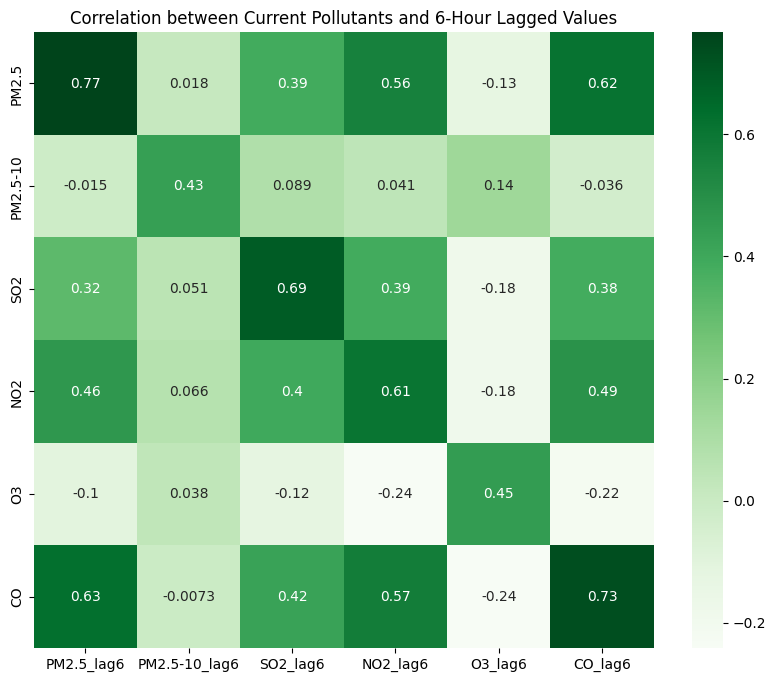

In [13]:
current_cols = pollutants
lag_cols = [f'{col}_lag6' for col in pollutants]

# Calculate correlation between them
lag_correlation = df_lagged[current_cols + lag_cols].corr()

# Filter the matrix to show only the relationship between a pollutant and its lag
# (We look at the intersection of current_cols and lag_cols)
plt.figure(figsize=(10, 8))
sns.heatmap(lag_correlation.loc[current_cols, lag_cols], annot=True, cmap='Greens')
plt.title('Correlation between Current Pollutants and 6-Hour Lagged Values')
plt.show()

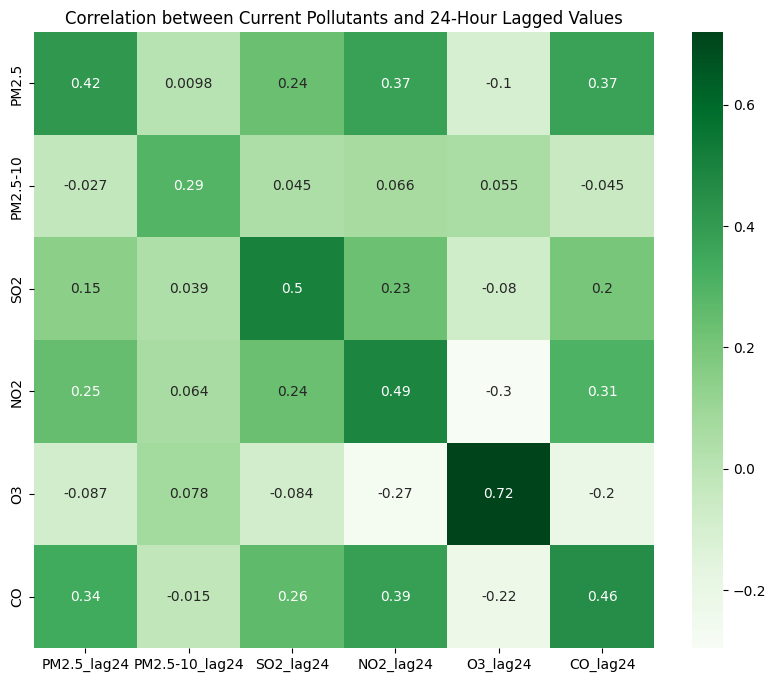

In [14]:
current_cols = pollutants
lag_cols = [f'{col}_lag24' for col in pollutants]

# Calculate correlation between them
lag_correlation = df_lagged[current_cols + lag_cols].corr()

# Filter the matrix to show only the relationship between a pollutant and its lag
# (We look at the intersection of current_cols and lag_cols)
plt.figure(figsize=(10, 8))
sns.heatmap(lag_correlation.loc[current_cols, lag_cols], annot=True, cmap='Greens')
plt.title('Correlation between Current Pollutants and 24-Hour Lagged Values')
plt.show()

# **Task 3: Model Building:**

### **Objective :**
* After completing all the tasks listed under Task 1 and Task 2, identify and implement the best practices
to build a suitable machine-learning model (e.g., feature scaling, encoding techniques, variable selection,
and parameter optimization).
* Justify your modelling decisions and evaluate model performance using appropriate metrics.

## Encoding

While one-hot encoding is more common, tree-based models like XGBoost can efficiently handle label-encoded categorical variables by finding optimal splits within the integer range. This keeps the feature space compact and reduces the dimensionality.

In [18]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

le_station = LabelEncoder()
df['station'] = le_station.fit_transform(df['station'])


## Rolling windows

Since the polutants don't just vanish imediatly or apear imediatly the previous values are highly predictable of the current values, the 6-hour window captures immediate atmospheric trends, while the 24-hour window accounts for daily cyclical patterns (e.g., morning/evening rush hour or diurnal temperature inversions). Using the .shift(1) prevents the model from seeing the current value it is trying to predict.

In [22]:
import pandas as pd

# Define the window sizes (e.g., 6 hours for immediate trend, 24 for daily cycle)
windows = [6, 24]
pollutants = ['PM2.5', 'PM2.5-10', 'SO2', 'NO2', 'CO', 'O3']

for p in pollutants:
    for w in windows:
        # Rolling Mean: Average over the window
        df[f'{p}_roll_mean_{w}'] = df.groupby('station')[p].transform(lambda x: x.shift(1).rolling(window=w).mean())

# Drop the rows that don't have enough history to fill the windows
df = df.dropna().reset_index(drop=True)

## Test/Train split
Air quality data is inherently a time-series. Standard random shuffling would lead to data leakage, where the model cheats by looking at future information to predict the past. Splitting the model choronologically ensures the model is evaluated on its ability to forecast future pollution levels based solely on historical patterns, mimicking real-world deployment.

In [ ]:
from xgboost import XGBRegressor
roll_cols = [c for c in df.columns if 'roll' in c]
weather_features = ['TEMP', 'DEWP', 'WSPM']
pres = ['PRES']
X_features = weather_features + roll_cols + pres

# Split data chronologically
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

X_train, y_train = train[X_features], train[pollutants]
X_test, y_test = test[X_features], test[pollutants]

## Feature selection

the six polutant models need different features, based on there correlation we saw in step 2.3.
* O3 : Temperature, Wind Speed, Dew Point Temperature and it's own rolling windows.
* PM2.5-10: only needs its own rolling window
* all the other polluants need all the rolling window features except O3 and PM2.5-10
* SO2: also needs pressure

## Model decision

Individual models were trained for each of the six pollutants? We do this because, each pollutant has distinct chemical drivers. For example, $O_3$ (Ozone) is highly dependent on solar radiation and temperature, whereas $SO_2$ is often linked to industrial output. Dedicated models allow the algorithm to optimize parameters for each specific pollutant's behavior

we implemented eXtreme Gradient Boosting (XGBoost) because:
* Non-Linearity: Air pollution is influenced by complex, non-linear interactions between weather (temp, rain) and chemical concentrations.
without requiring intensive feature scaling.
* Efficiency: It utilizes parallel processing, making it significantly faster than traditional Gradient Boosting for large datasets.

In [33]:
# Multi-output prediction loop
models = {}
for p in pollutants:
    p_specific_rolls = [c for c in roll_cols if p in c]
    if p == 'O3':
        features = weather_features+ p_specific_rolls
    elif p == 'PM2.5-10':
        features = p_specific_rolls
    else:
        features = [
            c for c in roll_cols
            if 'O3' not in c and 'PM2.5-10' not in c]
        if p == 'SO2':
          features = features+ pres


    print(f"Training model for {p}...")
    model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8
)
    model.fit(X_train[features], y_train[p])
    models[p] = model

Training model for PM2.5...
Training model for PM2.5-10...
Training model for SO2...
Training model for NO2...
Training model for CO...
Training model for O3...


## Evaluation

Now that the model is build we have to evaluate it. we do this using three metrics: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) and $R^2$ Score. The MAE gives us an intuitive measure of error in the same units as the pollutant concentration, The RMSE penalizes larger errors more heavily, which is verry important in air quality monitoring where missing a dangerous pollution spike is more important than a minor fluctuation and $R^2$ gives us the proportion of variance explained by the model, giving us  a standardized comparison across different pollutants making it easier to compair the models between polutants.

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

performance = {}

for p in pollutants:
    features = models[p].feature_names_in_
    # p_specific_rolls = [c for c in roll_cols if p in c]
    # if p == 'O3':
    #     features = weather_features+ p_specific_rolls
    # elif p == 'PM2.5-10':
    #     features = p_specific_rolls
    # else:
    #     features = [
    #         c for c in roll_cols
    #         if 'O3' not in c and 'PM2.5-10' not in c]
    #     if p == 'SO2':
    #       features = features+ pres


    y_pred = models[p].predict(X_test[features])

    #Calculate metrics
    mae = mean_absolute_error(y_test[p], y_pred)
    rmse = np.sqrt(mean_squared_error(y_test[p], y_pred))
    r2 = r2_score(y_test[p], y_pred)

    performance[p] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    # Store predictions back in the test dataframe for plotting
    test[f'{p}_pred'] = y_pred

# Display the results
performance_df = pd.DataFrame(performance).T
print("--- Model Performance on Test Data ---")
print(performance_df)

--- Model Performance on Test Data ---
                 MAE        RMSE        R2
PM2.5      20.971816   36.408834  0.807309
PM2.5-10   15.161765   23.824017  0.377387
SO2         3.386584    6.470679  0.628223
NO2        13.763492   19.428385  0.689326
CO        340.428287  626.528311  0.775951
O3         18.346381   28.111034  0.782831


## Saving
Lastly we save the model so we can use it in the streamlit app

In [ ]:
import joblib

# Define the file name
model_filename = 'air_quality_models.joblib'

# Save the dictionary containing all 6 models and the feature list
data_to_save = {
    'models': models,
    'features': X_features,
    'pollutants': pollutants
}

joblib.dump(data_to_save, model_filename)
print(f"Model saved as {model_filename}")

Model saved as air_quality_models.joblib


# **Task 4: Application Development**
 Develop an interactive application with a graphical user interface (GUI).

### **Objective :**
The dataset section,
* Visualization section, and
* Model outputs section

For the application go to https://progfordataanalysis-airpolution.streamlit.app/

## **The Application Design**


The application consists of two pages the interactive air quality dashboard and the predictions page.

The  interactive air quality dashboard is designed to provide a comprehensive platform for the analysis and visualization of atmospheric pollutant metrics. The application allows users to explore the Chineese air polution through an intuitive, filter-driven interface.

**Core Functionalities**

The dashboard facilitates station-level analysis, enabling users to isolate data from specific monitoring locations to identify regional variations. By utilizing a dynamic sidebar, users can refine their view based on a specific date range and select from various critical pollutants $PM_{2.5}$, $PM_{10}$, $SO_2$, $NO_2$, $CO$, and $O_3$.

**Adaptive Data Processing**

A key technical feature of this tool is its conditional resampling logic, which ensures data clarity across varying time scales.

Granular View: For timeframes of seven days or fewer, the dashboard displays the raw, hourly data, allowing for the observation of hourly fluctuations and peak events.

Trend Analysis: For selections exceeding seven days, the system automatically aggregates the data into daily averages. If the selection exceeds four monthes the system displays weekly averages and if the selection is bigger than a year we use monthly averages. This reduction in "noise" highlights broader environmental trends and seasonal patterns that would otherwise be hard to see because of the high-frequency volatility.

**Visualization**

The application pairs interactive time-series line charts with synchronized raw data tables. This dual-view approach allows for immediate visual interpretation of concentration trends over time while maintaining the transparency and integrity of the underlying numerical data.

**Model and Prediction**

The model page predicts the Air Quality of the next day. since the loaded data goes until 28th of February 2017 it predicts the Air Quality of the 1st of March 2017. It gives a clear overview of the most important statistics (the average PM2.5 and the average Ozone of the day), I than says the what level the Air Quality is over all and gives a line chart for the selected polutant over the day. The user can select which polutant they want the line chart to display. The predictions are based on the Air Quality of the previous day and the weather of the day. If we where to deploy the model to predict the Air Quality of tomorrow we would use the predicted weather.

# **Task 5: Version Control:**
### **Objective :**
* Use GitHub for version control.
* Commit changes regularly with clear, descriptive messages, for example, added PM2.5 prediction
model”, “Created correlation heatmap,” etc.
* Maintain an organised repository structure and include screenshots of:
* GitHub commit history
* GitHub project repository layout